# 03 — Modelling
## Malaria Cell Classification Using Deep Learning

**Project:** Malaria Cell Classification Using Deep Learning
**Author:** Kepha | Data Science Capstone Project in Collaboration with Ngao Labs

### Purpose of this notebook
Train and tune both models defined in the project plan, using the splits and artefacts persisted by
`02_preprocessing.ipynb` — no re-splitting, no re-deriving features, no path drift.

1. **Baseline** — Logistic Regression on the saved HOG + colour-histogram features.
2. **Primary model** — EfficientNetB0 transfer learning, trained in two phases (frozen backbone →
   fine-tune), with the decision threshold tuned to prioritise **recall on the parasitized class**,
   since a missed infection carries the highest human cost in this clinical triage context.
3. **Explainability** — Grad-CAM overlays on a handful of validation images from each class.

### Compute-efficiency choices made in this notebook
- Loads `preprocessing_config.json` rather than re-declaring constants, so image size / batch size /
  seed can never silently drift between notebooks.
- Rebuilds the `tf.data` pipelines with `.cache()` already applied — the first epoch decodes images
  once, every subsequent epoch (including the fine-tuning phase) reads from cache.
- Uses **mixed precision** (`mixed_float16`) automatically when a GPU is present, and stays in
  float32 on CPU-only machines where mixed precision offers no benefit.
- Trains in two short phases (frozen head, then a shallow fine-tune of only the top backbone layers)
  rather than fine-tuning the entire network from epoch 1 — this converges faster and is far cheaper
  than full end-to-end fine-tuning.
- `EarlyStopping` + `ModelCheckpoint` + `ReduceLROnPlateau` stop training as soon as validation
  performance plateaus, instead of running a fixed, wasteful epoch budget.

### Artefacts this notebook writes (to `models/`)
| Artefact | Purpose |
|---|---|
| `baseline_logreg.joblib` | Fitted Logistic Regression baseline |
| `efficientnetb0_final.keras` | Best fine-tuned EfficientNetB0 checkpoint |
| `decision_threshold.json` | Tuned decision threshold + the metrics that justified it |
| `training_history.csv` | Per-epoch metrics for both training phases, for reporting in `04_evaluation.ipynb` |


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Core libraries
import os
import json
import random
import zipfile

import numpy as np
import pandas as pd

# Baseline model
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve

# Deep learning
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

# Explainability
import matplotlib.pyplot as plt
import matplotlib.cm as cm

print("TensorFlow:", tf.__version__)
GPU_AVAILABLE = bool(tf.config.list_physical_devices("GPU"))
print("GPU available:", GPU_AVAILABLE)


TensorFlow: 2.20.0
GPU available: True


## 1. Load Preprocessing Config & Splits

Every constant below (image size, batch size, seed, directory paths) comes from
`preprocessing_config.json`, written by `02_preprocessing.ipynb` — this notebook never re-declares
values that could drift out of sync with how the data was actually prepared.


In [4]:
zip_path = "/content/drive/MyDrive/capstone-project/data/raw/data.zip"
extract_path = "/content/malaria_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")

Extraction completed.


In [5]:
PROCESSED_DIR = "/content/drive/MyDrive/capstone-project/data/processed"
MODELS_DIR = "/content/drive/MyDrive/capstone-project/models"
os.makedirs(MODELS_DIR, exist_ok=True)

with open(os.path.join(PROCESSED_DIR, "preprocessing_config.json")) as f:
    config = json.load(f)

RANDOM_SEED = config["random_seed"]
IMG_SIZE = tuple(config["img_size"])
BATCH_SIZE = config["batch_size"]

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Mixed precision only pays off with a GPU's tensor cores; stay in float32 on CPU.
if GPU_AVAILABLE:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Compute dtype policy:", tf.keras.mixed_precision.global_policy())

train_df = pd.read_csv(os.path.join(config["split_dir"], "train.csv"))
val_df = pd.read_csv(os.path.join(config["split_dir"], "val.csv"))
test_df = pd.read_csv(os.path.join(config["split_dir"], "test.csv"))

print(f"train: {len(train_df):,} | val: {len(val_df):,} | test: {len(test_df):,}")


Compute dtype policy: <DTypePolicy "mixed_float16">
train: 22,046 | val: 2,756 | test: 2,756


## 2. Baseline — Logistic Regression on HOG + Colour-Histogram Features

Loads the feature matrices saved by `02_preprocessing.ipynb` directly — the (comparatively slow) HOG
extraction step runs exactly once, in preprocessing, not here.


In [6]:
baseline_dir = config["baseline_dir"]

X_train = np.load(os.path.join(baseline_dir, "train_features.npy"))
y_train = np.load(os.path.join(baseline_dir, "train_labels.npy"))
X_val = np.load(os.path.join(baseline_dir, "val_features.npy"))
y_val = np.load(os.path.join(baseline_dir, "val_labels.npy"))

print(f"Baseline feature shapes — train: {X_train.shape}, val: {X_val.shape}")

baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight=None,   # dataset is balanced; no reweighting needed
    random_state=RANDOM_SEED,
    n_jobs=-1,            # use all available CPU cores — this is the main lever for a linear model
)
baseline_model.fit(X_train, y_train)

val_probs_baseline = baseline_model.predict_proba(X_val)[:, 1]
val_preds_baseline = (val_probs_baseline >= 0.5).astype(int)

print(classification_report(y_val, val_preds_baseline, target_names=["Uninfected", "Parasitized"]))
print(f"Val AUC-ROC: {roc_auc_score(y_val, val_probs_baseline):.4f}")

joblib.dump(baseline_model, os.path.join(MODELS_DIR, "baseline_logreg.joblib"))
print(f"Baseline saved to {os.path.join(MODELS_DIR, 'baseline_logreg.joblib')}")


Baseline feature shapes — train: (22046, 1860), val: (2756, 1860)
              precision    recall  f1-score   support

  Uninfected       0.84      0.87      0.85      1378
 Parasitized       0.86      0.84      0.85      1378

    accuracy                           0.85      2756
   macro avg       0.85      0.85      0.85      2756
weighted avg       0.85      0.85      0.85      2756

Val AUC-ROC: 0.9238
Baseline saved to /content/drive/MyDrive/capstone-project/models/baseline_logreg.joblib


## 3. Rebuild the `tf.data` Pipelines

Identical logic to `02_preprocessing.ipynb`, driven by the same config. Caching is **disk-based and
stores `uint8` pixels**, not an in-memory `float32` cache — a full in-memory cache of this dataset at
224×224×3 float32 would need ~16.5 GB of RAM, more than a standard Colab runtime (or many local
machines) provides, and reliably crashes the session. EfficientNet's `preprocess_input` scaling runs
as a cheap step *after* the cache, so the cache only ever stores the smaller decoded pixel data.


In [7]:
import shutil
CACHE_DIR = "/content/drive/MyDrive/capstone-project/data/processed/tfcache"
if os.path.exists(CACHE_DIR):
    shutil.rmtree(CACHE_DIR)
os.makedirs(CACHE_DIR, exist_ok=True)

In [8]:
AUTOTUNE = tf.data.AUTOTUNE
CACHE_DIR = "/content/drive/MyDrive/capstone-project/data/processed/tfcache" if os.path.exists("/content") else "./tfcache"   # local disk, not Drive
os.makedirs(CACHE_DIR, exist_ok=True)


def decode_and_resize(filepath, label):
    """Decode + resize only. Kept as uint8 so the on-disk cache stays small (4x smaller than float32)."""
    image = tf.io.read_file(filepath)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.uint8)
    return image, label


def apply_efficientnet_scaling(image, label):
    """Cheap per-batch step, applied after caching so the cache doesn't store float32 tensors."""
    image = preprocess_input(tf.cast(image, tf.float32))
    return image, label


def make_dataset(split_df, training, split_name, batch_size=BATCH_SIZE):
    filepaths = split_df["filepath"].to_numpy()
    labels = split_df["label"].to_numpy()

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)
    ds = ds.cache(os.path.join(CACHE_DIR, split_name))   # disk-based cache, not in-memory

    if training:
        ds = ds.shuffle(buffer_size=len(split_df), seed=RANDOM_SEED)

    ds = ds.map(apply_efficientnet_scaling, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, training=True, split_name="train")
val_ds = make_dataset(val_df, training=False, split_name="val")
test_ds = make_dataset(test_df, training=False, split_name="test")

augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical", seed=RANDOM_SEED),
    layers.RandomRotation(0.1, seed=RANDOM_SEED),
    layers.RandomContrast(0.1, seed=RANDOM_SEED),
], name="augmentation")


## 4. EfficientNetB0 Transfer-Learning Model

The augmentation layer is the first layer of the model graph (active only in training mode), so it
runs as part of the compiled/accelerated graph rather than as a Python-level `tf.data.map` bottleneck.

The backbone starts **frozen** — only the classification head trains in Phase 1, which is fast and
prevents large gradient updates from destroying the pretrained ImageNet features before the head has
learned anything useful.


In [8]:
def build_model(img_size, augmentation_layer, trainable_base=False):
    inputs = layers.Input(shape=(*img_size, 3))
    x = augmentation_layer(inputs)

    base_model = EfficientNetB0(include_top=False, weights="imagenet", input_tensor=x)
    base_model.trainable = trainable_base

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(0.3)(x)
    # Keep the output layer in float32 even under mixed precision, for numerically stable loss.
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)

    model = models.Model(inputs, outputs)
    return model, base_model


model, base_model = build_model(IMG_SIZE, augmentation, trainable_base=False)

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
    ],
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ augmentation[0][… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 5. Phase 1 — Train the Classification Head (Frozen Backbone)

`EarlyStopping` monitors validation AUC and restores the best weights automatically, so this cell
never trains longer than necessary.

**Resumable across sessions:** on platforms with session time limits (e.g. Colab), a single `.fit()`
call can get cut off mid-training. This cell checks for an existing checkpoint on disk first — if
one exists, it resumes from there instead of retraining from scratch, and epoch history is appended
to a CSV (not just held in memory) so the full record survives however many sessions it takes.
`EPOCHS_PHASE1` is kept small and this cell is simply re-run as many times as needed.


In [9]:
PHASE1_CKPT = os.path.join(MODELS_DIR, "efficientnetb0_phase1.keras")
PHASE1_HISTORY_PATH = os.path.join(MODELS_DIR, "phase1_history.csv")

if os.path.exists(PHASE1_CKPT):
    print(f"Found existing Phase 1 checkpoint — resuming: {PHASE1_CKPT}")
    model = tf.keras.models.load_model(PHASE1_CKPT)
else:
    print("No Phase 1 checkpoint found — starting Phase 1 from scratch.")
    # `model` was already built and compiled in the previous cell

EPOCHS_PHASE1 = 5  # small, session-friendly batch — re-run this cell as many times as needed;
                   # each run resumes from the last saved checkpoint instead of starting over

phase1_callbacks = [
    callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=3, restore_best_weights=True),
    callbacks.ModelCheckpoint(PHASE1_CKPT, monitor="val_auc", mode="max", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=2, min_lr=1e-6),
]

history_phase1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1,
    callbacks=phase1_callbacks,
)

# Append rather than overwrite — a timeout mid-training shouldn't lose earlier epochs' history
new_rows = pd.DataFrame(history_phase1.history)
new_rows.to_csv(PHASE1_HISTORY_PATH, mode="a", header=not os.path.exists(PHASE1_HISTORY_PATH), index=False)
print(f"Phase 1 history appended to {PHASE1_HISTORY_PATH}")


Found existing Phase 1 checkpoint — resuming: /content/drive/MyDrive/capstone-project/models/efficientnetb0_phase1.keras
Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 189s 159ms/step - auc: 0.9798 - loss: 0.1756 - precision: 0.9430 - recall: 0.9299 - val_auc: 0.9846 - val_loss: 0.1494 - val_precision: 0.9577 - val_recall: 0.9376 - learning_rate: 5.0000e-04
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 104s 105ms/step - auc: 0.9802 - loss: 0.1744 - precision: 0.9423 - recall: 0.9276 - val_auc: 0.9847 - val_loss: 0.1520 - val_precision: 0.9653 - val_recall: 0.9282 - learning_rate: 5.0000e-04
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 94s 116ms/step - auc: 0.9801 - loss: 0.1752 - precision: 0.9435 - recall: 0.9292 - val_auc: 0.9844 - val_loss: 0.1515 - val_precision: 0.9661 - val_recall: 0.9311 - learning_rate: 5.0000e-04
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 100s 114ms/step - auc: 0.9796 - loss: 0.1766 - precision: 0.9473 - recall: 0.9270 - val_auc: 0.9844 - val_loss: 0.1491 - val_precision: 0.9627 - val

## 6. Phase 2 — Fine-Tune the Top Backbone Layers

Only the **last 20 layers** of EfficientNetB0 are unfrozen — enough to adapt high-level features to
Giemsa-stained cell morphology, without the cost (or overfitting risk) of retraining the entire
backbone on a dataset this size. A much lower learning rate prevents large gradients from wiping out
the pretrained weights in the newly-unfrozen layers.

**Resumable across sessions**, same pattern as Phase 1: checks for an existing Phase 2 checkpoint
first and resumes from it if present. The backbone is looked up **by name inside the current
`model`** rather than via the separate `base_model` variable from the architecture cell — this
keeps the trainable-layer split correct whether `model` was just built fresh or reloaded from a
checkpoint, where that earlier `base_model` reference would otherwise be stale.


In [9]:
PHASE2_CKPT = os.path.join(MODELS_DIR, "efficientnetb0_final.keras")
PHASE2_HISTORY_PATH = os.path.join(MODELS_DIR, "phase2_history.csv")
FINE_TUNE_AT = -20  # unfreeze only the last 20 layers of the backbone

if os.path.exists(PHASE2_CKPT):
    print(f"Found existing Phase 2 checkpoint — resuming: {PHASE2_CKPT}")
    model = tf.keras.models.load_model(PHASE2_CKPT)
else:
    print("No Phase 2 checkpoint found — starting fine-tuning from the Phase 1 model.")

# EfficientNetB0 was built with input_tensor=x, so its layers are flattened directly
# into model.layers rather than nested under a sub-model — there's nothing named "efficientnet*".
HEAD_LAYER_NAMES = {"global_average_pooling2d", "dropout", "dense"}
backbone_layers = [
    l for l in model.layers
    if l.name not in HEAD_LAYER_NAMES and l.name not in ("input_layer", "augmentation")
]

for layer in backbone_layers:
    layer.trainable = False
for layer in backbone_layers[FINE_TUNE_AT:]:
    layer.trainable = True

# Note: recompiling resets optimizer momentum/adaptive state even when resuming — a small tradeoff
# for reliably re-applying the correct trainable-layer split on every resume.
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),   # 100x lower than Phase 1
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
    ],
)

trainable_count = sum(1 for l in backbone_layers if l.trainable)
print(f"Fine-tuning {trainable_count} / {len(backbone_layers)} backbone layers")

EPOCHS_PHASE2 = 5  # small, session-friendly batch — re-run this cell to continue fine-tuning

phase2_callbacks = [
    callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=3, restore_best_weights=True),
    callbacks.ModelCheckpoint(PHASE2_CKPT, monitor="val_auc", mode="max", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=2, min_lr=1e-7),
]

history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=phase2_callbacks,
)

new_rows = pd.DataFrame(history_phase2.history)
new_rows.to_csv(PHASE2_HISTORY_PATH, mode="a", header=not os.path.exists(PHASE2_HISTORY_PATH), index=False)
print(f"Phase 2 history appended to {PHASE2_HISTORY_PATH}")


Found existing Phase 2 checkpoint — resuming: /content/drive/MyDrive/capstone-project/models/efficientnetb0_final.keras
Fine-tuning 20 / 237 backbone layers
Epoch 1/5


KeyboardInterrupt: 

Reads the **persisted** per-phase history CSVs rather than the in-memory `history_phase1` /
`history_phase2` objects — since training may have spanned several resumed sessions, only the CSVs
(appended to on every run of the Phase 1/2 cells above) hold the complete epoch-by-epoch record.


In [ ]:
phase1_history_df = pd.read_csv(PHASE1_HISTORY_PATH).assign(phase=1)
phase2_history_df = pd.read_csv(PHASE2_HISTORY_PATH).assign(phase=2)

history_df = pd.concat([phase1_history_df, phase2_history_df], ignore_index=True)
history_df.to_csv(os.path.join(MODELS_DIR, "training_history.csv"), index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, metric in zip(axes, ["auc", "recall", "precision"]):
    ax.plot(history_df[metric], label="train")
    ax.plot(history_df[f"val_{metric}"], label="val")
    ax.axvline(len(phase1_history_df) - 0.5, color="gray", linestyle="--", label="fine-tune start")
    ax.set_title(metric.upper())
    ax.set_xlabel("epoch")
    ax.legend()
plt.tight_layout()
plt.show()


In [10]:
import os
print(os.path.exists(PHASE2_CKPT), os.path.getmtime(PHASE2_CKPT) if os.path.exists(PHASE2_CKPT) else None)

True 1786294444.0


## 7. Decision Threshold Tuning

The default 0.5 threshold is rarely optimal for a clinical-safety objective. Here we sweep thresholds
against validation predictions and pick the **highest threshold that still achieves ≥97% recall** on
the parasitized class — maximising precision (and therefore reducing unnecessary follow-up testing)
without compromising the recall floor the project targets.


In [11]:
val_probs = model.predict(val_ds).ravel()
val_labels = val_df["label"].to_numpy()

precision, recall, thresholds = precision_recall_curve(val_labels, val_probs)

TARGET_RECALL = 0.97
valid = recall[:-1] >= TARGET_RECALL   # recall/precision have one more element than thresholds
if valid.any():
    best_idx = np.where(valid)[0][np.argmax(precision[:-1][valid])]
    decision_threshold = float(thresholds[best_idx])
else:
    decision_threshold = 0.5
    print(f"No threshold reached {TARGET_RECALL:.0%} recall on validation data — defaulting to 0.5.")

val_preds = (val_probs >= decision_threshold).astype(int)
print(f"Chosen decision threshold: {decision_threshold:.4f}")
print(classification_report(val_labels, val_preds, target_names=["Uninfected", "Parasitized"]))

with open(os.path.join(MODELS_DIR, "decision_threshold.json"), "w") as f:
    json.dump({
        "decision_threshold": decision_threshold,
        "target_recall": TARGET_RECALL,
        "val_auc": float(roc_auc_score(val_labels, val_probs)),
    }, f, indent=2)


87/87 ━━━━━━━━━━━━━━━━━━━━ 66s 368ms/step
Chosen decision threshold: 0.2153
              precision    recall  f1-score   support

  Uninfected       0.97      0.94      0.96      1378
 Parasitized       0.94      0.97      0.96      1378

    accuracy                           0.96      2756
   macro avg       0.96      0.96      0.96      2756
weighted avg       0.96      0.96      0.96      2756



## 8. Grad-CAM Explainability

Highlights the cell regions driving each prediction, using the last convolutional layer of the
EfficientNetB0 backbone (`top_conv`). As noted in the project's limitations, these overlays indicate
attention regions but are not clinical-grade explainability evidence.


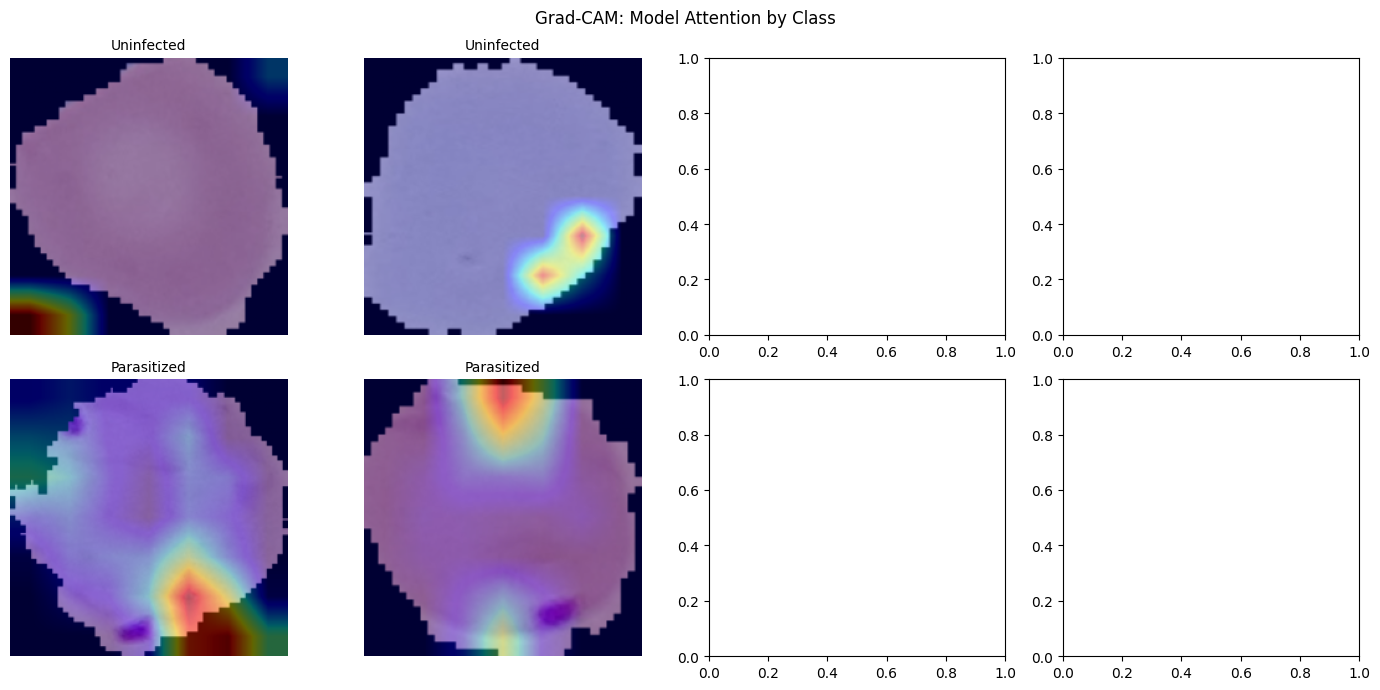

In [12]:
LAST_CONV_LAYER = "top_conv"


def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        model.inputs, [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(image, heatmap, alpha=0.4):
    heatmap_resized = tf.image.resize(heatmap[..., tf.newaxis], IMG_SIZE).numpy().squeeze()
    heatmap_colored = cm.jet(heatmap_resized)[..., :3]

    display_img = (image - image.min()) / (image.max() - image.min() + 1e-8)
    overlaid = display_img * (1 - alpha) + heatmap_colored * alpha
    return overlaid


# Pull a few examples from each class for a qualitative check
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for images, labels in val_ds.take(1):
    for cls, label_value in [("Uninfected", 0), ("Parasitized", 1)]:
        idxs = np.where(labels.numpy() == label_value)[0][:2]
        for col, i in enumerate(idxs):
            img_array = tf.expand_dims(images[i], axis=0)
            heatmap = make_gradcam_heatmap(img_array, model, LAST_CONV_LAYER)
            overlaid = overlay_gradcam(images[i].numpy(), heatmap)

            row = 0 if label_value == 0 else 1
            axes[row, col].imshow(overlaid)
            axes[row, col].set_title(cls, fontsize=10)
            axes[row, col].axis("off")
    break

plt.suptitle("Grad-CAM: Model Attention by Class")
plt.tight_layout()
plt.show()


## 9. Summary & Next Steps

**Artefacts written to `models/`:**
- `baseline_logreg.joblib` — fitted Logistic Regression baseline
- `efficientnetb0_phase1.keras` — best head-only checkpoint (frozen backbone)
- `efficientnetb0_final.keras` — best fine-tuned checkpoint (final model)
- `training_history.csv` — per-epoch metrics across both training phases
- `decision_threshold.json` — tuned decision threshold + the validation metrics that justified it

**Carried forward to `04_evaluation.ipynb`:**
- Load `efficientnetb0_final.keras` and `decision_threshold.json` to score the held-out **test** split
  (not touched in this notebook) and report final recall/precision/F1/AUC-ROC, plus the disaggregated
  per-class breakdown described in the project README.
- Load `baseline_logreg.joblib` to report the baseline comparison table alongside the final model.
- Re-use the Grad-CAM functions above (or re-import them) to generate the explainability figures for
  the final report.
- Carry the fine-tuned Keras model into the TensorFlow.js export step for browser deployment.
